# 09 — Unified Evaluation Notebook

Single evaluation script for any trained GAN (WaveNet, TimeGAN, QuantGAN, etc.).

**Protocol:**
- Evaluation in **MinMaxScaled [0,1]** space (same basis for all models)
- For `lambert` preprocessing: generator output is inverse-transformed (CDF⁻¹ → scaler2⁻¹ → Gaussianize⁻¹ → scaler1⁻¹) then MinMaxScaled
- Real data: **non-overlapping** windows (stride = `SEQ_LEN`)
- Matched sample sizes (real = synthetic count)
- Noise distribution matches the model being evaluated

**Metrics:**
1. Distribution fidelity — MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence
2. Temporal dynamics — ACF RMSE (returns + squared returns)
3. Geometric distance — Fréchet Distance, DTW
4. Tail behaviour — Mean/Std/Skewness/Kurtosis differences
5. Discriminative score — MLP classifier
6. GRU classifier — Fidelity (accuracy + AUC on 3D sequences)
7. TSTR — Train on Synthetic, Test on Real (usefulness)
8. Visual diagnostics — PCA, t-SNE, sample sequences, distributions
9. Entropy — Shannon, Lempel-Ziv complexity, plug-in entropy
10. QuantGAN metrics — DY (log-density divergence), ACF score (3 transforms), leverage effect (Wiese et al., 2020)

## 0. Configuration

Change this cell to switch between models.

In [ ]:
# ============================================================
# MODEL CONFIGURATION — change this block to evaluate a
# different generator.  Everything downstream is parameterized.
# ============================================================

MODEL_NAME       = 'WaveNet Lambert-GAN'
GENERATOR_PATH   = '../models/wavenet_lambert_generator.keras'
NOISE_TYPE       = 'normal'    # 'normal' for WaveNet / Hybrid, 'uniform' for TimeGAN
Z_DIM            = 32          # latent dimension (must match training)
SEQ_LEN          = 24         # sequence length (must match training)
N_FEATURES       = 1          # single feature: log returns
N_SAMPLES        = 100        # synthetic sequences to generate

# --- Preprocessing pipeline ---
# 'minmax'  : MinMaxScaler [0,1] — WaveNet-GAN (NB07), TimeGAN, etc.
# 'lambert' : StandardScaler → Gaussianize → StandardScaler → CDF[-1,1] — NB12
PREPROCESSING    = 'lambert'

# --- Hybrid-specific: multi-model pipeline ---
# Set to None for single-model generators (e.g. pure WaveNet GAN)
SUPERVISOR_PATH  =  None #'../models/hybrid_wavenet_supervisor.keras'
RECOVERY_PATH    =  None #'../models/hybrid_wavenet_recovery.keras'

# ============================================================
# Example configs (uncomment one block):
# ============================================================
# --- WaveNet-GAN (NB07, default) ---
# MODEL_NAME     = 'WaveNet-GAN'
# GENERATOR_PATH = '../models/wavenet_generator.keras'
# PREPROCESSING  = 'minmax'
# NOISE_TYPE     = 'normal'

# --- WaveNet-GAN + Lambert W (NB12) ---
# MODEL_NAME     = 'WaveNet-GAN+Lambert'
# GENERATOR_PATH = '../models/wavenet_lambert_generator.keras'
# PREPROCESSING  = 'lambert'
# NOISE_TYPE     = 'normal'

# --- QuantGAN (NB11) ---
# MODEL_NAME     = 'QuantGAN'
# GENERATOR_PATH = '../models/quantgan_generator.keras'
# PREPROCESSING  = 'lambert'
# NOISE_TYPE     = 'normal'

## 1. Imports & Data Loading

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import load_model

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Make utils importable
sys.path.append('..')
import importlib
import utils.evaluation_metrics as _eval_mod
importlib.reload(_eval_mod)
from utils.evaluation_metrics import (
    compute_mmd_per_channel,
    compute_acf_per_channel,
    compute_acf_vectors,
    compute_distribution_per_channel,
    compute_tail_metrics_per_channel,
    compute_discriminative_score,
    compute_frechet_distance,
    compute_dtw_distance,
    compute_js_divergence_3d_dynamic_bins,
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-06 14:47:06.276788: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load SP500 data (identical to NB07 cell 4)
data = pd.read_csv('../data/raw/sp500.csv', index_col='Date', parse_dates=True)
data = data.apply(pd.to_numeric, errors='coerce')

close_prices = data['Close']
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
log_returns_array = log_returns.values.reshape(-1, 1)

# ── Preprocessing pipeline ──────────────────────────────────
if PREPROCESSING == 'lambert':
    from sklearn.preprocessing import StandardScaler
    from scipy.stats import norm as sp_norm
    from utils.gaussianize import Gaussianize

    # Stage 1: StandardScaler (centre + normalize)
    scaler1 = StandardScaler()
    stage1 = scaler1.fit_transform(log_returns_array)

    # Stage 2: Gaussianize (Lambert W inverse — remove heavy tails)
    gaussianizer = Gaussianize(max_iter=100, tol=1e-6)
    stage2 = gaussianizer.fit_transform(stage1)

    # Stage 3: StandardScaler (re-standardize Gaussianized output → ~N(0,1))
    scaler2 = StandardScaler()
    stage3 = scaler2.fit_transform(stage2.reshape(-1, 1))

    # Stage 4: Normal CDF → Uniform(0,1) → rescale to [-1,1]
    # Fills tanh range uniformly (unlike MinMaxScaler which concentrates in center)
    stage4_uniform = sp_norm.cdf(stage3)
    log_returns_gaussianized = (2.0 * stage4_uniform - 1.0).astype(np.float32)

    print(f"Preprocessing: StandardScaler → Gaussianize(δ={gaussianizer.delta_[0]:.6f}) → StandardScaler → CDF[-1,1]")
    print(f"Gaussianized range (stage 3): [{stage3.min():.4f}, {stage3.max():.4f}]")
    print(f"CDF-mapped range  (stage 4): [{log_returns_gaussianized.min():.4f}, {log_returns_gaussianized.max():.4f}]")

# MinMaxScaler for evaluation space (always fitted on real data)
scaler = MinMaxScaler()
log_returns_scaled = scaler.fit_transform(log_returns_array)

# --- NON-OVERLAPPING windows (stride = SEQ_LEN) ---
# This avoids inflating sample count with near-duplicate data
n_total = len(log_returns_scaled)
n_windows = n_total // SEQ_LEN
sequences = np.array([
    log_returns_scaled[i * SEQ_LEN : (i + 1) * SEQ_LEN]
    for i in range(n_windows)
], dtype=np.float32)  # shape: (n_windows, SEQ_LEN, 1)

print(f"Total log returns: {n_total}")
print(f"Non-overlapping windows (stride={SEQ_LEN}): {sequences.shape}")
print(f"Scaled range: [{sequences.min():.4f}, {sequences.max():.4f}]")

Preprocessing: StandardScaler → Gaussianize(δ=1.712322) → StandardScaler → MinMax[-1,1]
Gaussianized range (stage 3): [-2.9601, 2.8183]
Tanh-ready range  (stage 4): [-1.0000, 1.0000]
Total log returns: 6036
Non-overlapping windows (stride=24): (251, 24, 1)
Scaled range: [0.0000, 1.0000]


## 2. Load Generator & Generate Synthetic Data

In [ ]:
# Load generator
generator = load_model(GENERATOR_PATH)
print(f"Loaded generator from {GENERATOR_PATH}")
print(f"  Input shape:  {generator.input_shape}")
print(f"  Output shape: {generator.output_shape}")

# --- Load supervisor + recovery for hybrid pipeline ---
supervisor, recovery_net = None, None
if SUPERVISOR_PATH and RECOVERY_PATH:
    supervisor = load_model(SUPERVISOR_PATH)
    recovery_net = load_model(RECOVERY_PATH)
    print(f"Loaded supervisor from {SUPERVISOR_PATH}")
    print(f"Loaded recovery  from {RECOVERY_PATH}")
    print(f"  Pipeline: Z → Generator → Supervisor → Recovery → X̃")
else:
    print(f"  Pipeline: Z → Generator → X̃  (single model)")

# Match sample count to real non-overlapping windows
n_eval = min(N_SAMPLES, len(sequences))

# Generate noise (distribution matches training)
if NOISE_TYPE == 'normal':
    Z = tf.random.normal(shape=(n_eval, SEQ_LEN, Z_DIM), mean=0.0, stddev=1.0)
elif NOISE_TYPE == 'uniform':
    Z = tf.random.uniform(shape=(n_eval, SEQ_LEN, Z_DIM), minval=0.0, maxval=1.0)
else:
    raise ValueError(f"Unknown NOISE_TYPE: {NOISE_TYPE}")

# Generate synthetic data
if supervisor is not None and recovery_net is not None:
    # Hybrid pipeline: Generator → Supervisor → Recovery
    E_hat = generator(Z, training=False)
    H_hat = supervisor(E_hat, training=False)
    raw_synthetic = recovery_net(H_hat, training=False).numpy()
else:
    # Single-model pipeline
    raw_synthetic = generator(Z, training=False).numpy()

# ── Inverse-transform for Lambert W models ──────────────────
if PREPROCESSING == 'lambert':
    # Generator output is in tanh [-1,1] space → invert 4-stage pipeline
    # CDF⁻¹ (norm.ppf) → scaler2⁻¹ → gaussianizer⁻¹ → scaler1⁻¹ → log returns
    # then MinMaxScale to [0,1] for evaluation
    synth_flat = raw_synthetic.reshape(-1, 1)

    # Stage 4 inverse: [-1,1] → [0,1] → Φ⁻¹ → N(0,1)
    synth_uniform = np.clip((synth_flat + 1.0) / 2.0, 1e-7, 1 - 1e-7)
    inv4 = sp_norm.ppf(synth_uniform)
    # scaler2⁻¹
    inv3 = scaler2.inverse_transform(inv4)
    # gaussianizer⁻¹
    inv2 = gaussianizer.inverse_transform(inv3.ravel()).reshape(-1, 1)
    # scaler1⁻¹  → original log-return space
    synth_log_returns = scaler1.inverse_transform(inv2)

    # MinMaxScale to [0,1] for unified evaluation
    synthetic_sequences = scaler.transform(synth_log_returns).reshape(
        n_eval, SEQ_LEN, N_FEATURES
    ).astype(np.float32)

    print(f"\n  Lambert W inverse transform applied (4-stage CDF)")
    print(f"  Generator output range: [{raw_synthetic.min():.4f}, {raw_synthetic.max():.4f}]")
    print(f"  Log-return range:       [{synth_log_returns.min():.6f}, {synth_log_returns.max():.6f}]")
    print(f"  MinMax [0,1] range:     [{synthetic_sequences.min():.4f}, {synthetic_sequences.max():.4f}]")
else:
    # Already in [0,1] space
    synthetic_sequences = raw_synthetic

# Real data — take first n_eval non-overlapping windows
real_sequences = sequences[:n_eval]  # (n_eval, SEQ_LEN, 1)

# Flatten to 2D for metrics that need (n, seq_len) shape
real_2d = real_sequences.reshape(n_eval, SEQ_LEN)
synth_2d = synthetic_sequences.reshape(n_eval, SEQ_LEN)

print(f"\nEvaluation shapes:")
print(f"  Real:      {real_sequences.shape}")
print(f"  Synthetic: {synthetic_sequences.shape}")
print(f"  Noise:     {NOISE_TYPE}, z_dim={Z_DIM}")
print(f"  Preprocessing: {PREPROCESSING}")

I0000 00:00:1772833628.000214 2176329 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1964 MB memory:  -> device: 0, name: Quadro P620, pci bus id: 0000:01:00.0, compute capability: 6.1


Loaded generator from ../models/wavenet_lambert_generator.keras
  Input shape:  (None, 24, 32)
  Output shape: (None, 24, 1)
  Pipeline: Z → Generator → X̃  (single model)


2026-03-06 14:47:09.255638: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90600



  Lambert W inverse transform applied (4-stage)
  Generator output range: [-0.4741, 0.5385]
  Log-return range:       [-0.013856, 0.016064]
  MinMax [0,1] range:     [0.4797, 0.6058]

Evaluation shapes:
  Real:      (100, 24, 1)
  Synthetic: (100, 24, 1)
  Noise:     normal, z_dim=32
  Preprocessing: lambert


## 3. Summary Statistics (Sanity Check)

In [5]:
# Quick sanity check before running expensive metrics
# All stats computed in [0,1] scaled space
stats = pd.DataFrame({
    'Real': [real_2d.mean(), real_2d.std(), real_2d.min(), real_2d.max(),
             np.median(real_2d)],
    'Synthetic': [synth_2d.mean(), synth_2d.std(), synth_2d.min(), synth_2d.max(),
                  np.median(synth_2d)],
}, index=['Mean', 'Std', 'Min', 'Max', 'Median'])
stats['Delta'] = stats['Synthetic'] - stats['Real']

print(f"Summary Statistics (scaled [0,1] space) — {MODEL_NAME}")
print(stats.to_string(float_format='{:.6f}'.format))

# Also show stats in original log-return space for interpretability
real_rescaled = scaler.inverse_transform(real_2d.reshape(-1, 1)).flatten()
synth_rescaled = scaler.inverse_transform(synth_2d.reshape(-1, 1)).flatten()

stats_raw = pd.DataFrame({
    'Real': [real_rescaled.mean(), real_rescaled.std(), real_rescaled.min(),
             real_rescaled.max()],
    'Synthetic': [synth_rescaled.mean(), synth_rescaled.std(), synth_rescaled.min(),
                  synth_rescaled.max()],
}, index=['Mean', 'Std', 'Min', 'Max'])
stats_raw['Delta'] = stats_raw['Synthetic'] - stats_raw['Real']

print(f"\nSummary Statistics (original log-return space)")
print(stats_raw.to_string(float_format='{:.6f}'.format))
if PREPROCESSING == 'lambert':
    print(f"\n  (Lambert W inverse applied before MinMaxScale — values are in original space)")

Summary Statistics (scaled [0,1] space) — WaveNet Lambert-GAN
           Real  Synthetic     Delta
Mean   0.537367   0.541203  0.003835
Std    0.059700   0.017374 -0.042326
Min    0.138928   0.479699  0.340771
Max    1.000000   0.605823 -0.394177
Median 0.539908   0.541933  0.002025

Summary Statistics (original log-return space)
          Real  Synthetic     Delta
Mean -0.000176   0.000734  0.000910
Std   0.014162   0.004122 -0.010041
Min  -0.094695  -0.013856  0.080839
Max   0.109572   0.016064 -0.093508

  (Lambert W inverse applied before MinMaxScale — values are in original space)


## 4A. Distribution Fidelity

MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence.

In [6]:
# ============================================
# MMD (multi-scale RBF, per-channel)
# ============================================
mmd_results = compute_mmd_per_channel(real_sequences, synthetic_sequences,
                                       num_samples=n_eval)
print(f"MMD (multi-scale RBF): {mmd_results['mean']:.6f}")
for ch, val in mmd_results.items():
    if ch != 'mean':
        print(f"  {ch}: {val:.6f}")

# ============================================
# Wasserstein-1 & KS test
# ============================================
dist_results = compute_distribution_per_channel(real_sequences, synthetic_sequences)
print(f"\nWasserstein-1 (mean): {dist_results['mean_wasserstein']:.6f}")
print(f"KS statistic (mean): {dist_results['mean_ks']:.4f}")
for ch in dist_results['wasserstein']:
    print(f"  {ch}: W={dist_results['wasserstein'][ch]:.6f}, "
          f"KS={dist_results['ks_statistic'][ch]:.4f}, "
          f"p={dist_results['ks_pvalue'][ch]:.4f}")

# ============================================
# JS Divergence
# ============================================
js_similarity = compute_js_divergence_3d_dynamic_bins(real_sequences, synthetic_sequences)
js_divergence = (100 - js_similarity) / 100  # Convert back to [0,1] divergence
print(f"\nJS Divergence: {js_divergence:.6f}")
print(f"JS Similarity: {js_similarity:.2f}%")

MMD (multi-scale RBF): 0.059113
  Open: 0.059113

Wasserstein-1 (mean): 0.026193
KS statistic (mean): 0.2175
  Open: W=0.026193, KS=0.2175, p=0.0000

JS Divergence: 0.440545
JS Similarity: 55.95%


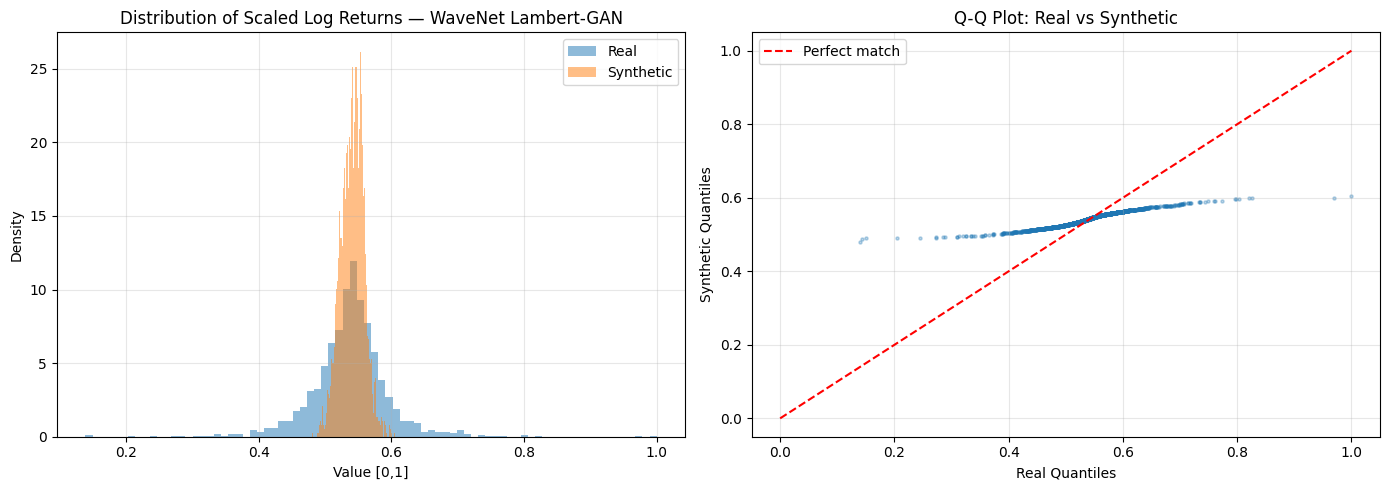

In [7]:
# Distribution plots — histogram + QQ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of scaled values (all time-steps pooled)
axes[0].hist(real_2d.flatten(), bins=80, alpha=0.5, density=True, label='Real')
axes[0].hist(synth_2d.flatten(), bins=80, alpha=0.5, density=True, label='Synthetic')
axes[0].set_title(f'Distribution of Scaled Log Returns — {MODEL_NAME}')
axes[0].set_xlabel('Value [0,1]')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# QQ plot
real_sorted = np.sort(real_2d.flatten())
synth_sorted = np.sort(synth_2d.flatten())
n_qq = min(len(real_sorted), len(synth_sorted))
axes[1].scatter(
    real_sorted[np.linspace(0, len(real_sorted)-1, n_qq, dtype=int)],
    synth_sorted[np.linspace(0, len(synth_sorted)-1, n_qq, dtype=int)],
    alpha=0.3, s=5
)
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect match')
axes[1].set_title('Q-Q Plot: Real vs Synthetic')
axes[1].set_xlabel('Real Quantiles')
axes[1].set_ylabel('Synthetic Quantiles')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4B. Temporal Dynamics

Autocorrelation RMSE for returns and squared returns (volatility clustering).

ACF RMSE (returns):         0.053456
ACF RMSE (squared returns): 0.050862


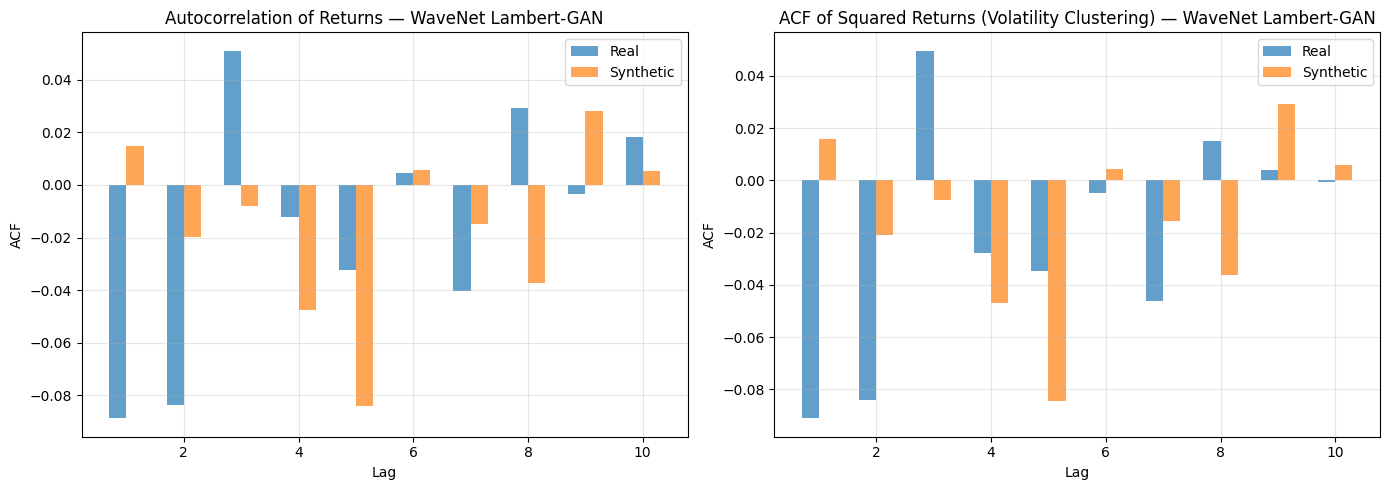

In [8]:
# ACF comparison — uses compute_acf_vectors for plotting
acf = compute_acf_vectors(real_sequences, synthetic_sequences, max_lag=10)
lags = acf['lags']

# Also get scalar RMSE from compute_acf_per_channel (for summary table later)
acf_rmse_results = compute_acf_per_channel(real_sequences, synthetic_sequences, max_lag=10)

# Get the first (only) channel
ch_name = list(acf['returns'].keys())[0]
ret = acf['returns'][ch_name]
sq = acf['squared'][ch_name]

print(f"ACF RMSE (returns):         {ret['rmse']:.6f}")
print(f"ACF RMSE (squared returns): {sq['rmse']:.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lags - 0.15, ret['real'], width=0.3, label='Real', alpha=0.7)
axes[0].bar(lags + 0.15, ret['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
axes[0].set_title(f'Autocorrelation of Returns — {MODEL_NAME}')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(lags - 0.15, sq['real'], width=0.3, label='Real', alpha=0.7)
axes[1].bar(lags + 0.15, sq['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
axes[1].set_title(f'ACF of Squared Returns (Volatility Clustering) — {MODEL_NAME}')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4C. Geometric / Embedding Distance

Fréchet Distance (joint) and DTW.

In [9]:
# ============================================
# Fréchet Distance (joint, per-channel)
# ============================================
fd_results = compute_frechet_distance(real_sequences, synthetic_sequences, per_channel=True)
print(f"Fréchet Distance (joint):       {fd_results['overall_fd']:.6f}")
print(f"Fréchet Distance (avg channel): {fd_results['average_channel_fd']:.6f}")
for ch, val in fd_results['channel_fd'].items():
    print(f"  {ch}: {val:.6f}")

# ============================================
# DTW Distance (subsampled for speed)
# ============================================
n_dtw = min(50, n_eval)  # DTW is O(n²) per pair — subsample
dtw_real = real_sequences[:n_dtw]
dtw_synth = synthetic_sequences[:n_dtw]
dtw_score = compute_dtw_distance(dtw_real, dtw_synth)
print(f"\nDTW Distance (mean, n={n_dtw}): {dtw_score:.6f}")

Fréchet Distance (joint):       0.001805
Fréchet Distance (avg channel): 0.001805
  Channel_0: 0.001805

DTW Distance (mean, n=50): 17.940808


## 4D. Tail Behaviour & Higher-Order Statistics

Mean, std, skewness, and kurtosis differences — critical for financial risk modelling.

Tail metrics (Open):
  Mean diff:      0.003835
  Std ratio:      0.2910  (1.0 = perfect)
  Skewness diff:  0.0518
  Kurtosis diff:  7.4884


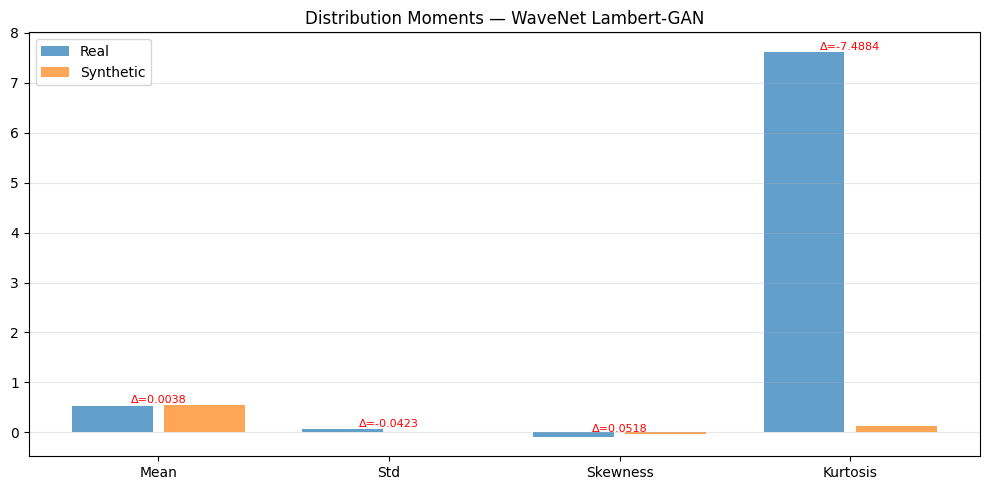

In [10]:
from scipy.stats import skew, kurtosis

tail_results = compute_tail_metrics_per_channel(real_sequences, synthetic_sequences)

ch_name = list(tail_results['mean_diff'].keys())[0]
print(f"Tail metrics ({ch_name}):")
print(f"  Mean diff:      {tail_results['mean_diff'][ch_name]:.6f}")
print(f"  Std ratio:      {tail_results['std_ratio'][ch_name]:.4f}  (1.0 = perfect)")
print(f"  Skewness diff:  {tail_results['skew_diff'][ch_name]:.4f}")
print(f"  Kurtosis diff:  {tail_results['kurtosis_diff'][ch_name]:.4f}")

# Bar chart — real vs synthetic moment values
real_flat = real_2d.flatten()
synth_flat = synth_2d.flatten()
moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']
real_moments = [np.mean(real_flat), np.std(real_flat),
                skew(real_flat), kurtosis(real_flat)]
synth_moments = [np.mean(synth_flat), np.std(synth_flat),
                 skew(synth_flat), kurtosis(synth_flat)]

x = np.arange(len(moment_names))
fig, ax = plt.subplots(figsize=(10, 5))
bars_r = ax.bar(x - 0.2, real_moments, 0.35, label='Real', alpha=0.7)
bars_s = ax.bar(x + 0.2, synth_moments, 0.35, label='Synthetic', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(moment_names)
ax.set_title(f'Distribution Moments — {MODEL_NAME}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate deltas
for i, (r, s) in enumerate(zip(real_moments, synth_moments)):
    delta = s - r
    ax.annotate(f'Δ={delta:.4f}', xy=(i, max(r, s)),
                ha='center', va='bottom', fontsize=8, color='red')

plt.tight_layout()
plt.show()

## 4E. Discriminative Score

MLP classifier trained to distinguish real from synthetic.  
Score = |accuracy − 0.5|. Lower = better (indistinguishable).

In [11]:
disc_results = compute_discriminative_score(real_sequences, synthetic_sequences)
print(f"Discriminative Accuracy: {disc_results['accuracy']:.4f}")
print(f"Discriminative Score:    {disc_results['score']:.4f}  (closer to 0 = better)")

Discriminative Accuracy: 0.8000
Discriminative Score:    0.3000  (closer to 0 = better)


/opt/synthetic-financial-data/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## 4F. GRU Classifier — Fidelity Assessment

A GRU-based time series classifier trained to distinguish real from synthetic
sequences on the **full 3D data** (preserving temporal structure).  
Adapted from the original TimeGAN evaluation (Yoon et al. 2019).

GRU Classifier — Test Accuracy: 0.5000, AUC: 0.5000, Score: 0.0000


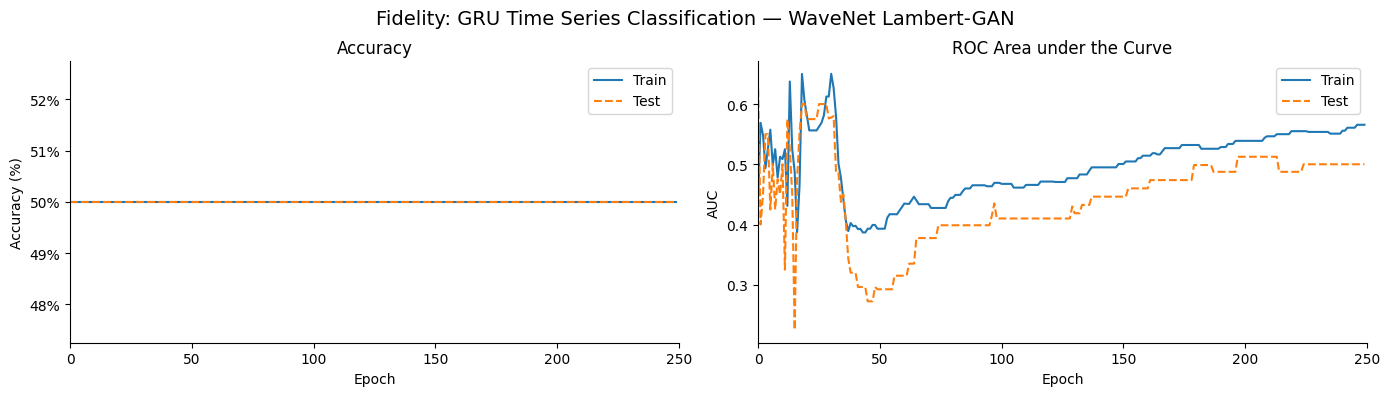

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.metrics import AUC
from matplotlib.ticker import FuncFormatter

# --- Prepare labelled dataset (3D) ---
n_series = n_eval
idx = np.arange(n_series)
n_train = int(0.8 * n_series)
train_idx, test_idx = idx[:n_train], idx[n_train:]

train_data = np.vstack((real_sequences[train_idx], synthetic_sequences[train_idx]))
test_data  = np.vstack((real_sequences[test_idx],  synthetic_sequences[test_idx]))

n_train_cls, n_test_cls = len(train_idx), len(test_idx)
train_labels = np.concatenate([np.ones(n_train_cls), np.zeros(n_train_cls)])
test_labels  = np.concatenate([np.ones(n_test_cls),  np.zeros(n_test_cls)])

# --- Build GRU classifier ---
gru_classifier = Sequential([
    Input(shape=(SEQ_LEN, N_FEATURES)),
    GRU(24, name='GRU'),
    Dense(1, activation='sigmoid', name='OUT')
], name='TS_Classifier')

gru_classifier.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=[AUC(name='AUC'), 'accuracy'])

gru_result = gru_classifier.fit(
    x=train_data, y=train_labels,
    validation_data=(test_data, test_labels),
    epochs=250, batch_size=128, verbose=0
)

gru_test_loss, gru_test_auc, gru_test_acc = gru_classifier.evaluate(
    test_data, test_labels, verbose=0
)
gru_disc_score = abs(0.5 - gru_test_acc)

print(f"GRU Classifier — Test Accuracy: {gru_test_acc:.4f}, "
      f"AUC: {gru_test_auc:.4f}, Score: {gru_disc_score:.4f}")

# --- Plot training curves ---
history = pd.DataFrame(gru_result.history)
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))

history[['accuracy', 'val_accuracy']].rename(
    columns={'accuracy': 'Train', 'val_accuracy': 'Test'}
).plot(ax=axes[0], title='Accuracy', style=['-', '--'], xlim=(0, 250))
axes[0].set_xlabel('Epoch')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Accuracy (%)')

history[['AUC', 'val_AUC']].rename(
    columns={'AUC': 'Train', 'val_AUC': 'Test'}
).plot(ax=axes[1], title='ROC Area under the Curve',
       style=['-', '--'], xlim=(0, 250))
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')

sns.despine()
fig.suptitle(f'Fidelity: GRU Time Series Classification — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

## 4G. TSTR — Train on Synthetic, Test on Real (Usefulness)

Train a GRU regression model to predict the next time step.  
Compare: model trained on **synthetic** vs model trained on **real** data,  
both tested on held-out real data.  If the synthetic-trained model performs  
comparably, the synthetic data is *useful* for downstream ML tasks.

TSTR MAE (Train Synthetic, Test Real): 0.056190
TRTR MAE (Train Real, Test Real):      0.059242
TSTR / TRTR ratio:                     0.9485  (closer to 1.0 = better)


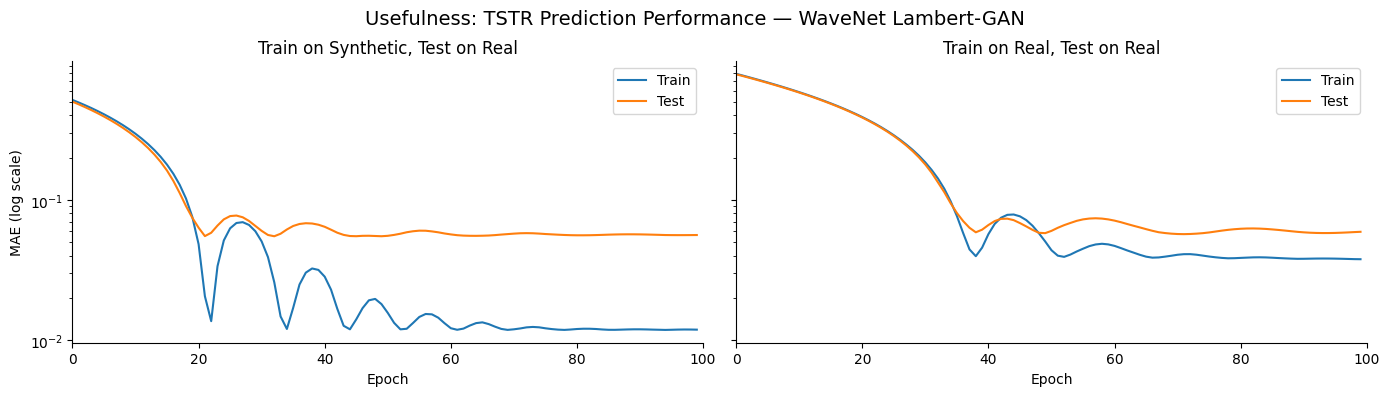

In [13]:
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam

# --- Split sequences: input = t[0:-1], label = t[-1] ---
real_train_X = real_sequences[train_idx, :-1, :]   # (n_train, SEQ_LEN-1, 1)
real_train_y = real_sequences[train_idx, -1, :]     # (n_train, 1)
real_test_X  = real_sequences[test_idx, :-1, :]
real_test_y  = real_sequences[test_idx, -1, :]

synth_train_X = synthetic_sequences[:, :-1, :]      # use all synthetic for training
synth_train_y = synthetic_sequences[:, -1, :]

def build_predictor():
    model = Sequential([
        Input(shape=(SEQ_LEN - 1, N_FEATURES)),
        GRU(24),
        Dense(N_FEATURES)
    ])
    model.compile(optimizer=Adam(), loss=MeanAbsoluteError(name='MAE'))
    return model

# --- Train on Synthetic, Test on Real ---
tstr_model = build_predictor()
tstr_result = tstr_model.fit(
    x=synth_train_X, y=synth_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
tstr_mae = tstr_model.evaluate(real_test_X, real_test_y, verbose=0)

# --- Train on Real, Test on Real (baseline) ---
trtr_model = build_predictor()
trtr_result = trtr_model.fit(
    x=real_train_X, y=real_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
trtr_mae = trtr_model.evaluate(real_test_X, real_test_y, verbose=0)

print(f"TSTR MAE (Train Synthetic, Test Real): {tstr_mae:.6f}")
print(f"TRTR MAE (Train Real, Test Real):      {trtr_mae:.6f}")
print(f"TSTR / TRTR ratio:                     {tstr_mae / trtr_mae:.4f}  (closer to 1.0 = better)")

# --- Plot training curves ---
tstr_hist = pd.DataFrame(tstr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})
trtr_hist = pd.DataFrame(trtr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})

fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)
tstr_hist.plot(ax=axes[0], title='Train on Synthetic, Test on Real',
               logy=True, xlim=(0, 100))
trtr_hist.plot(ax=axes[1], title='Train on Real, Test on Real',
               logy=True, xlim=(0, 100))
for i in [0, 1]:
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MAE (log scale)')

sns.despine()
fig.suptitle(f'Usefulness: TSTR Prediction Performance — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

## 5. Visual Diagnostics

PCA, t-SNE, and sample sequence comparison.

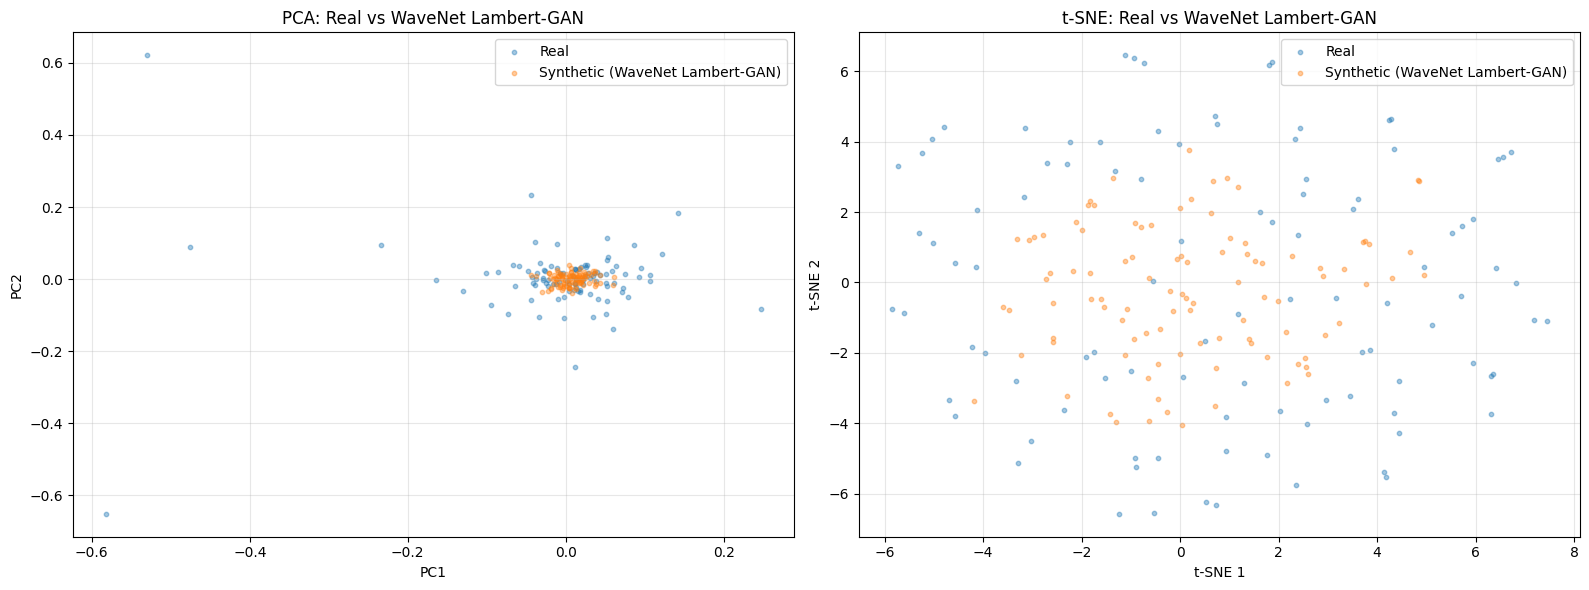

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Combine real & synthetic 2D arrays
combined = np.vstack([real_2d, synth_2d])
labels = np.array([0] * n_eval + [1] * n_eval)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined)
axes[0].scatter(pca_result[labels==0, 0], pca_result[labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[0].scatter(pca_result[labels==1, 0], pca_result[labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[0].set_title(f'PCA: Real vs {MODEL_NAME}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE (subsample for speed)
n_tsne = min(500, n_eval)
idx_real = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval)
idx_synth = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval) + n_eval
idx_all = np.concatenate([idx_real, idx_synth])

tsne = TSNE(n_components=2, perplexity=min(30, n_tsne - 1), random_state=42)
tsne_result = tsne.fit_transform(combined[idx_all])
tsne_labels = labels[idx_all]

axes[1].scatter(tsne_result[tsne_labels==0, 0], tsne_result[tsne_labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[1].scatter(tsne_result[tsne_labels==1, 0], tsne_result[tsne_labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[1].set_title(f't-SNE: Real vs {MODEL_NAME}')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

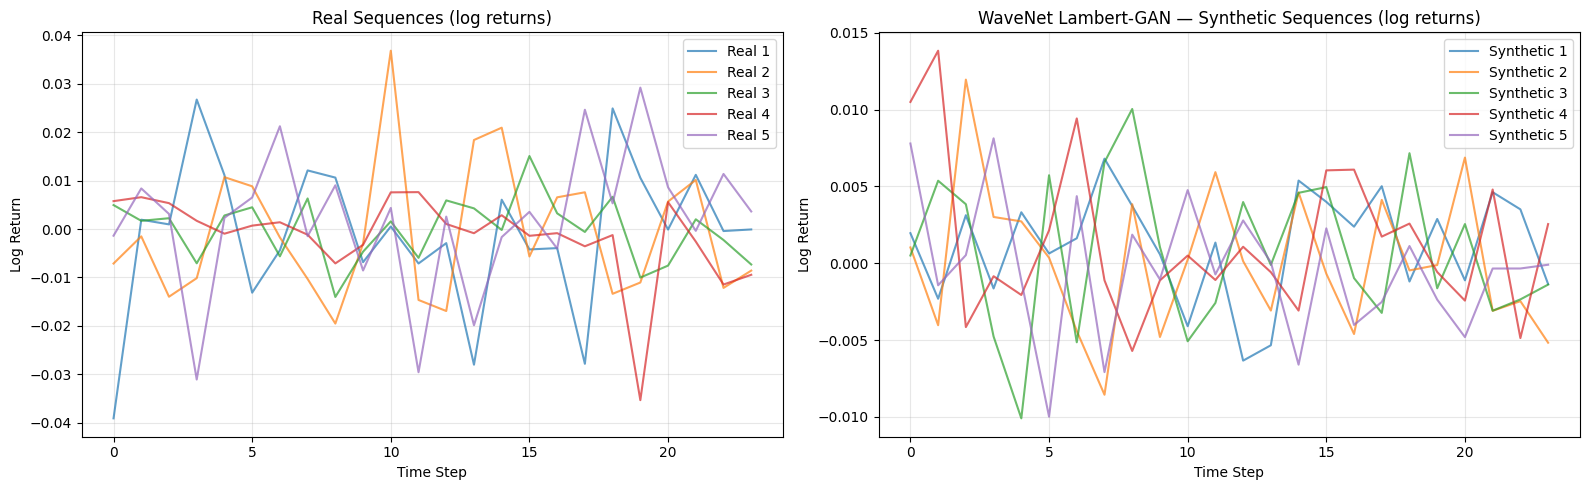

In [15]:
# Sample sequences — 5 real vs 5 synthetic (in original log-return space)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pick 5 well-separated real windows
plot_idx = np.linspace(0, n_eval - 1, 5, dtype=int)

# Rescale to log-return space for interpretability
real_plot = scaler.inverse_transform(
    real_sequences[plot_idx].reshape(-1, 1)
).reshape(5, SEQ_LEN)
synth_plot = scaler.inverse_transform(
    synthetic_sequences[:5].reshape(-1, 1)
).reshape(5, SEQ_LEN)

for i in range(5):
    axes[0].plot(real_plot[i], alpha=0.7, label=f'Real {i+1}')
axes[0].set_title('Real Sequences (log returns)')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Log Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i in range(5):
    axes[1].plot(synth_plot[i], alpha=0.7, label=f'Synthetic {i+1}')
axes[1].set_title(f'{MODEL_NAME} — Synthetic Sequences (log returns)')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Log Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5b. Entropy Analysis

Compare the information-theoretic structure of real vs synthetic sequences using three complementary entropy measures:

- **Shannon Entropy** — measures marginal randomness of the discretised series
- **Lempel-Ziv Complexity** — captures pattern/substring diversity (mode-collapse detector)
- **Plug-in Entropy (word=2)** — captures transition / bigram structure

Values are computed after quantile-binning each series into 5 equal-frequency bins. A good generator should closely match the real data's entropy on all three measures.

In [16]:
from utils.evaluation_metrics import compute_entropy_metrics

entropy_results = compute_entropy_metrics(real_sequences, synthetic_sequences, n_bins=5)

ch = list(entropy_results['shannon_real'].keys())[0]

print("=" * 65)
print(f"  {MODEL_NAME} — Entropy Analysis")
print("=" * 65)
print(f"  {'Metric':<35} {'Real':>10} {'Synth':>10} {'|Δ|':>10}")
print("-" * 65)
print(f"  {'Shannon Entropy (bits)':<35} "
      f"{entropy_results['shannon_real'][ch]:>10.4f} "
      f"{entropy_results['shannon_synth'][ch]:>10.4f} "
      f"{entropy_results['shannon_diff'][ch]:>10.4f}")
print(f"  {'Lempel-Ziv Complexity':<35} "
      f"{entropy_results['lz_real'][ch]:>10.4f} "
      f"{entropy_results['lz_synth'][ch]:>10.4f} "
      f"{entropy_results['lz_diff'][ch]:>10.4f}")
print(f"  {'Plug-in Entropy (w=2, bits)':<35} "
      f"{entropy_results['plugin2_real'][ch]:>10.4f} "
      f"{entropy_results['plugin2_synth'][ch]:>10.4f} "
      f"{entropy_results['plugin2_diff'][ch]:>10.4f}")
print("=" * 65)

# Interpretation
lz_ratio = entropy_results['lz_synth'][ch] / max(entropy_results['lz_real'][ch], 1e-8)
if lz_ratio < 0.85:
    print("\n  ⚠  LZ complexity is significantly LOWER than real data → possible mode collapse")
elif lz_ratio > 1.15:
    print("\n  ⚠  LZ complexity is significantly HIGHER than real data → over-random / noisy")
else:
    print("\n  ✓  LZ complexity is within 15% of real data → good pattern diversity")

sh_diff = entropy_results['shannon_diff'][ch]
if sh_diff < 0.05:
    print("  ✓  Shannon entropy match is excellent (Δ < 0.05 bits)")
elif sh_diff < 0.15:
    print("  ~  Shannon entropy match is acceptable (Δ < 0.15 bits)")
else:
    print(f"  ⚠  Shannon entropy gap is large (Δ = {sh_diff:.4f} bits)")

  WaveNet Lambert-GAN — Entropy Analysis
  Metric                                    Real      Synth        |Δ|
-----------------------------------------------------------------
  Shannon Entropy (bits)                  2.3219     1.8156     0.5064
  Lempel-Ziv Complexity                   0.2525     0.2133     0.0392
  Plug-in Entropy (w=2, bits)             4.6207     3.6222     0.9985

  ⚠  LZ complexity is significantly LOWER than real data → possible mode collapse
  ⚠  Shannon entropy gap is large (Δ = 0.5064 bits)


## 5c. QuantGAN-style Metrics (Wiese et al., 2020)

Three metrics from the original Quant GANs paper (arXiv:1907.06673):

- **DY metric** (Drǎgulescu & Yakovenko, 2002) — log-density divergence at multiple time lags (1, 5, 20 days). Measures distributional fidelity across different return horizons.
- **ACF score** — L2 norm of ACF difference for three transforms: $f(x) = x$ (serial), $f(x) = x^2$ (squared/vol clustering), $f(x) = |x|$ (absolute). Captures temporal dependence structure.
- **Leverage effect score** — Compares $\text{Corr}(r_{t+\tau}^2, r_t)$ curves. Captures the asymmetric negative correlation between volatility and returns (a key stylized fact).

  WaveNet Lambert-GAN — QuantGAN Metrics (Wiese et al., 2020)

  DY Metric (log-density divergence, lower = better):
    DY(1)          233.1185
    DY(5)          192.8523
    DY(20)         228.8292
    DY(100)        225.5285

  ACF Score (L2 norm of ACF difference, lower = better):
    ACF(x)  — serial                   0.5253
    ACF(x²) — squared                  0.5173
    ACF(|x|) — absolute                0.5253

  Leverage Effect Score (L2, lower = better):
    Score                              0.5528


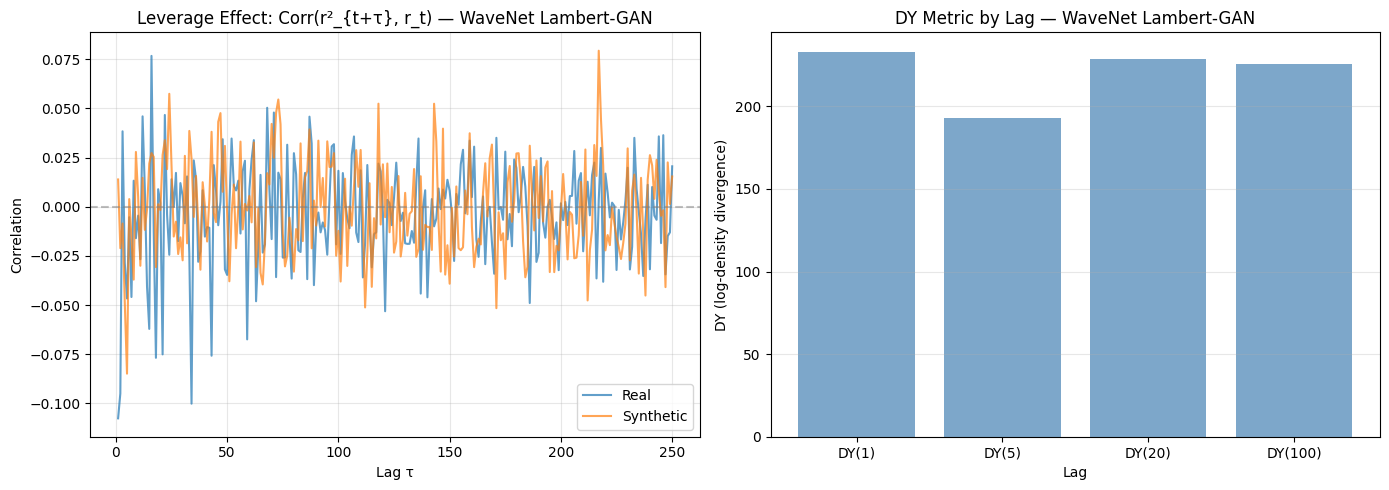

In [17]:
from utils.evaluation_metrics import (
    compute_dy_metric, compute_quantgan_acf_score, compute_leverage_effect_score
)

# Flatten to 1-D series for QuantGAN metrics
real_flat = real_2d.flatten()
synth_flat = synth_2d.flatten()

# --- DY Metric (multi-lag distributional divergence) ---
# Use lags 1,5,20 (100 requires very long series — skip if too short)
max_feasible_lag = min(len(real_flat), len(synth_flat)) // 2
dy_lags = tuple(l for l in (1, 5, 20, 100) if l < max_feasible_lag)
dy_results = compute_dy_metric(real_flat, synth_flat, lags=dy_lags)

print("=" * 65)
print(f"  {MODEL_NAME} — QuantGAN Metrics (Wiese et al., 2020)")
print("=" * 65)
print(f"\n  DY Metric (log-density divergence, lower = better):")
for key, val in dy_results.items():
    print(f"    {key:<12} {val:>10.4f}")

# --- ACF Score (3-transform, L2 norm) ---
# Clamp to available sequence length
acf_max_lag = min(250, len(real_flat) // 4)
qacf = compute_quantgan_acf_score(real_flat, synth_flat, max_lag=acf_max_lag)

print(f"\n  ACF Score (L2 norm of ACF difference, lower = better):")
print(f"    {'ACF(x)  — serial':<30} {qacf['acf_identity']:>10.4f}")
print(f"    {'ACF(x²) — squared':<30} {qacf['acf_squared']:>10.4f}")
print(f"    {'ACF(|x|) — absolute':<30} {qacf['acf_absolute']:>10.4f}")

# --- Leverage Effect Score ---
lev = compute_leverage_effect_score(real_flat, synth_flat,
                                     max_lag=min(250, len(real_flat) // 4))

print(f"\n  Leverage Effect Score (L2, lower = better):")
print(f"    {'Score':<30} {lev['leverage_score']:>10.4f}")
print("=" * 65)

# --- Plot leverage effect curves ---
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Leverage effect
lags_lev = np.arange(1, len(lev['leverage_real']) + 1)
axes[0].plot(lags_lev, lev['leverage_real'], label='Real', alpha=0.7)
axes[0].plot(lags_lev, lev['leverage_synth'], label='Synthetic', alpha=0.7)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title(f'Leverage Effect: Corr(r²_{{t+τ}}, r_t) — {MODEL_NAME}')
axes[0].set_xlabel('Lag τ')
axes[0].set_ylabel('Correlation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DY metric bar chart
dy_keys = list(dy_results.keys())
dy_vals = list(dy_results.values())
axes[1].bar(dy_keys, dy_vals, alpha=0.7, color='steelblue')
axes[1].set_title(f'DY Metric by Lag — {MODEL_NAME}')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('DY (log-density divergence)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Summary Dashboard

All scalar metrics in one table.

In [18]:
ch = list(tail_results['mean_diff'].keys())[0]

print("=" * 65)
print(f"  {MODEL_NAME} — Evaluation Summary")
print("=" * 65)
print(f"  {'Metric':<45} {'Value':>12}")
print("-" * 65)

# Distribution fidelity
print(f"  {'MMD (multi-scale RBF) ↓':<45} {mmd_results['mean']:>12.6f}")
print(f"  {'Wasserstein-1 ↓':<45} {dist_results['mean_wasserstein']:>12.6f}")
print(f"  {'KS statistic ↓':<45} {dist_results['mean_ks']:>12.4f}")
print(f"  {'KS p-value ↑':<45} {list(dist_results['ks_pvalue'].values())[0]:>12.4f}")
print(f"  {'JS divergence ↓':<45} {js_divergence:>12.6f}")

# Temporal dynamics
print(f"  {'ACF RMSE (returns) ↓':<45} {ret['rmse']:>12.6f}")
print(f"  {'ACF RMSE (squared returns) ↓':<45} {sq['rmse']:>12.6f}")

# Geometric
print(f"  {'Fréchet Distance (joint) ↓':<45} {fd_results['overall_fd']:>12.6f}")
print(f"  {'DTW distance (mean) ↓':<45} {dtw_score:>12.6f}")

# Tail metrics
print(f"  {'Mean diff → 0':<45} {tail_results['mean_diff'][ch]:>12.6f}")
print(f"  {'Std ratio → 1.0':<45} {tail_results['std_ratio'][ch]:>12.4f}")
print(f"  {'Skewness diff → 0':<45} {tail_results['skew_diff'][ch]:>12.4f}")
print(f"  {'Kurtosis diff → 0':<45} {tail_results['kurtosis_diff'][ch]:>12.4f}")

# Discriminative (MLP)
print(f"  {'MLP Disc. score ↓':<45} {disc_results['score']:>12.4f}")
print(f"  {'MLP Disc. accuracy → 0.5':<45} {disc_results['accuracy']:>12.4f}")

# GRU classifier (fidelity)
print(f"  {'GRU Disc. score ↓':<45} {gru_disc_score:>12.4f}")
print(f"  {'GRU Disc. accuracy → 0.5':<45} {gru_test_acc:>12.4f}")
print(f"  {'GRU AUC → 0.5':<45} {gru_test_auc:>12.4f}")

# TSTR (usefulness)
print(f"  {'TSTR MAE (Synth→Real) ↓':<45} {tstr_mae:>12.6f}")
print(f"  {'TRTR MAE (Real→Real) ↓':<45} {trtr_mae:>12.6f}")
print(f"  {'TSTR/TRTR ratio → 1.0':<45} {tstr_mae / trtr_mae:>12.4f}")

# Entropy (information-theoretic)
_ech = list(entropy_results['shannon_real'].keys())[0]
print(f"  {'Shannon Entropy |Δ| (bits) ↓':<45} {entropy_results['shannon_diff'][_ech]:>12.4f}")
print(f"  {'Lempel-Ziv Complexity |Δ| ↓':<45} {entropy_results['lz_diff'][_ech]:>12.4f}")
print(f"  {'Plug-in Entropy w=2 |Δ| (bits) ↓':<45} {entropy_results['plugin2_diff'][_ech]:>12.4f}")

# QuantGAN-style metrics (Wiese et al., 2020)
for key, val in dy_results.items():
    print(f"  {f'{key} (log-density div.) ↓':<45} {val:>12.4f}")
print(f"  {'ACF Score (identity) ↓':<45} {qacf['acf_identity']:>12.4f}")
print(f"  {'ACF Score (squared) ↓':<45} {qacf['acf_squared']:>12.4f}")
print(f"  {'ACF Score (absolute) ↓':<45} {qacf['acf_absolute']:>12.4f}")
print(f"  {'Leverage Effect Score ↓':<45} {lev['leverage_score']:>12.4f}")

print("=" * 65)
print(f"\n  Scale: MinMaxScaled [0,1] | Windows: non-overlapping (stride={SEQ_LEN})")
print(f"  Preprocessing: {PREPROCESSING}")
print(f"  Samples: {n_eval} real, {n_eval} synthetic | Noise: {NOISE_TYPE}")

  WaveNet Lambert-GAN — Evaluation Summary
  Metric                                               Value
-----------------------------------------------------------------
  MMD (multi-scale RBF) ↓                           0.059113
  Wasserstein-1 ↓                                   0.026193
  KS statistic ↓                                      0.2175
  KS p-value ↑                                        0.0000
  JS divergence ↓                                   0.440545
  ACF RMSE (returns) ↓                              0.053456
  ACF RMSE (squared returns) ↓                      0.050862
  Fréchet Distance (joint) ↓                        0.001805
  DTW distance (mean) ↓                            17.940808
  Mean diff → 0                                     0.003835
  Std ratio → 1.0                                     0.2910
  Skewness diff → 0                                   0.0518
  Kurtosis diff → 0                                   7.4884
  MLP Disc. score ↓                  